In [ ]:
import pandas as pd

df = pd.concat([
    pd.read_csv("rdu_2024.csv.gz", compression="gzip"),
    pd.read_csv("rdu_2025.csv.gz", compression="gzip")
], ignore_index=True)
Val_df=pd.DataFrame("export.csv")
print(df.tail(20))
print(df.info())
print(Val_df.info())
print(Val_df.head(20))
print(Val_df.tail(20))

       year  month  day  hour  temp temp_source  rhum rhum_source  prcp  \
15723  2025     10   17     3   6.7  dwd_mosmix    99  dwd_mosmix   0.0   
15724  2025     10   17     4   6.8  dwd_mosmix    97  dwd_mosmix   0.0   
15725  2025     10   17     5   6.7  dwd_mosmix    95  dwd_mosmix   0.0   
15726  2025     10   17     6   7.3  dwd_mosmix    92  dwd_mosmix   0.0   
15727  2025     10   17     7   7.8  dwd_mosmix    90  dwd_mosmix   0.0   
15728  2025     10   17     8   8.5  dwd_mosmix    87  dwd_mosmix   0.0   
15729  2025     10   17     9   9.4  dwd_mosmix    84  dwd_mosmix   0.0   
15730  2025     10   17    10  10.4  dwd_mosmix    80  dwd_mosmix   0.0   
15731  2025     10   17    11  11.0  dwd_mosmix    76  dwd_mosmix   0.0   
15732  2025     10   17    12  11.7  dwd_mosmix    73  dwd_mosmix   0.0   
15733  2025     10   17    13  12.4  dwd_mosmix    70  dwd_mosmix   0.0   
15734  2025     10   17    14  12.5  dwd_mosmix    70  dwd_mosmix   0.0   
15735  2025     10   17  

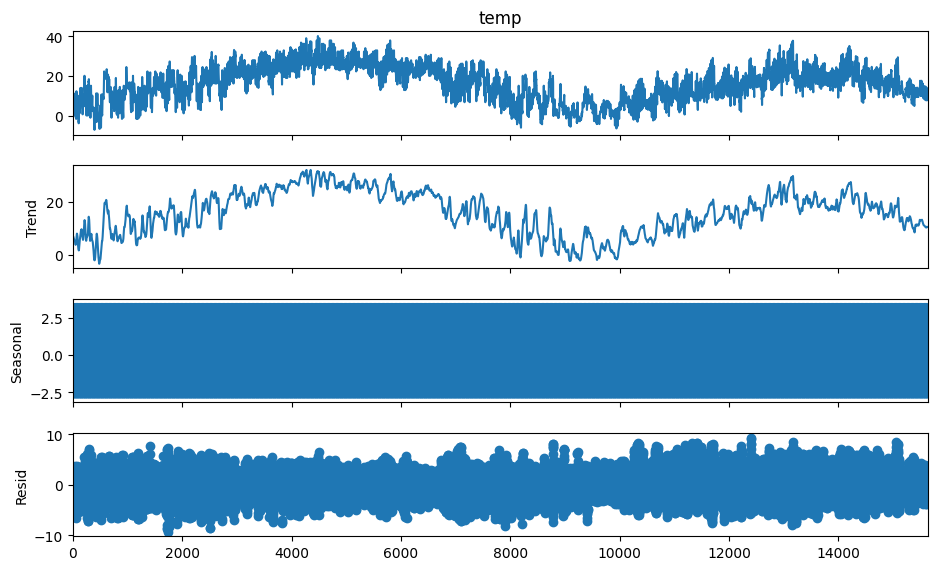

In [20]:

import statsmodels.api as sm
decomposition = sm.tsa.seasonal_decompose(df["temp"], model = 'additive',period=24)
fig = decomposition.plot()
fig.set_size_inches(10, 6)
import matplotlib.pyplot as plt
plt.show()


In [ ]:
from prophet import Prophet

# Combine year, month, day, and hour into the required 'ds' datetime column
df['ds'] = pd.to_datetime(
    df[['year', 'month', 'day', 'hour']]
    .assign(minute=0) # Ensures exact hourly timestamps
)

df_prophet = df.rename(columns={'temp': 'y'})
df_prophet = df_prophet[['ds', 'y']].copy()

# Initialize Prophet with full seasonality (crucial for hourly data)
model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True,
    interval_width=0.95
)

model.fit(df_prophet)
forecast_year = 2025 

start_date = pd.to_datetime(f'{forecast_year}-09-17 00:00:00')
end_date = pd.to_datetime(f'{forecast_year}-09-30 23:00:00')

# Create a future DataFrame with every hour (freq='H')
future_dates = pd.date_range(start=start_date, end=end_date, freq='H')
df_future = pd.DataFrame({'ds': future_dates})

# Generate the forecast
forecast = model.predict(df_future)

# Select the date and the predicted temperature columns
df_prediction = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

print("Hourly Temperature Forecast for Sep 17-30, 2025 (First 5 Rows):")
print(df_prediction.head())
print(f"\nTotal predicted hourly points: {len(df_prediction)}")

16:15:07 - cmdstanpy - INFO - Chain [1] start processing
16:15:09 - cmdstanpy - INFO - Chain [1] done processing


Hourly Temperature Forecast for Sep 17-30, 2025 (First 5 Rows):
                   ds       yhat  yhat_lower  yhat_upper
0 2025-09-17 00:00:00  15.177339    5.625911   23.793356
1 2025-09-17 01:00:00  14.359024    5.589019   23.307811
2 2025-09-17 02:00:00  13.743808    4.646882   22.809414
3 2025-09-17 03:00:00  13.303281    3.818131   22.690157
4 2025-09-17 04:00:00  13.000937    4.792315   22.334608

Total predicted hourly points: 336


/var/folders/rn/5rl0r6jn4ws28cl_m7v_mf7h0000gn/T/ipykernel_5473/3086751497.py:27: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  future_dates = pd.date_range(start=start_date, end=end_date, freq='H')
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: divide by zero encoun